<div align="center">
  <h2>🛒 Market Basket Optimization: Apriori Algorithm</h2>
  <p>Discovering hidden patterns in customer purchasing behavior.</p>
</div>

### 1. Importing Essential Libraries
We will use `pandas` for data manipulation, `mlxtend` for the Apriori algorithm, and `seaborn`/`networkx` for advanced visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### 2. Loading the Dataset
The dataset contains 7,500 transactions from a French retail store over a week. Since it lacks a header, we treat each row as an individual transaction.

In [17]:
df = pd.read_csv("Market_Basket_Optimisation.csv", header=None)
print(f"Data Shape: {df.shape}")

df.head()

Data Shape: (7501, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Exploratory Data Analysis (EDA)
Before generating rules, let's look at the most popular items. This helps establish a baseline for our business insights.

C:\Users\artin\AppData\Local\Temp\ipykernel_10928\940821073.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_counts.values, y=item_counts.index, palette="mako")


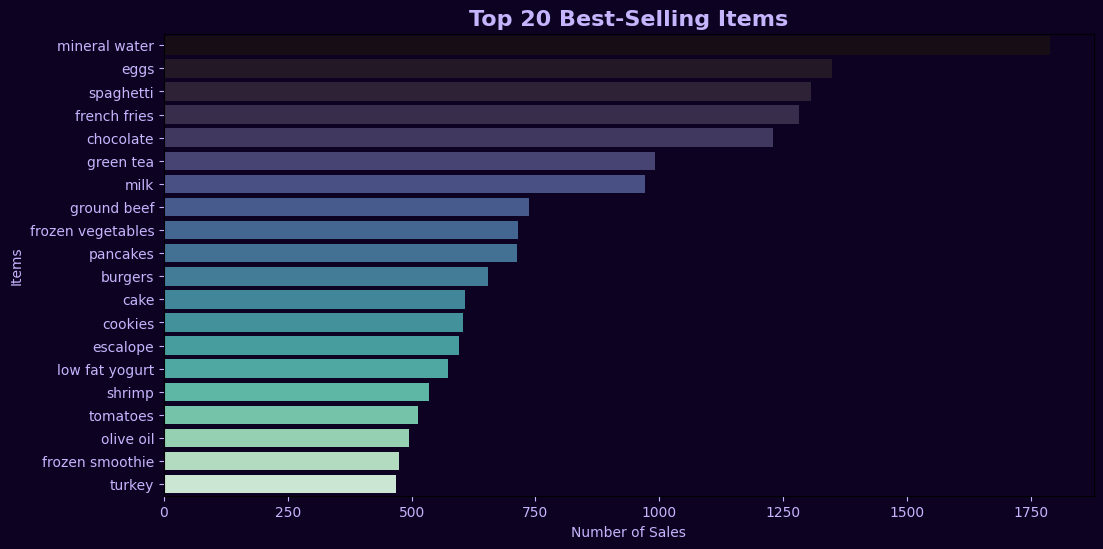

In [12]:
# Flattening the dataset to count item frequencies
all_items = df.values.flatten()
all_items = [item for item in all_items if str(item) != "nan"]
item_counts = pd.Series(all_items).value_counts().head(20)

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#0d0221')
plt.gcf().patch.set_facecolor('#0d0221')

sns.barplot(x=item_counts.values, y=item_counts.index, palette="mako")
plt.title("Top 20 Best-Selling Items", fontsize=16, fontweight='bold', color='#c4b5fd')
plt.xlabel("Number of Sales", color='#c4b5fd')
plt.ylabel("Items", color='#c4b5fd')
plt.tick_params(colors='#c4b5fd')
plt.show()

### 4. Data Preprocessing (Transaction Encoding)
The `apriori` function requires a boolean matrix (True/False for each item in each transaction). We use `TransactionEncoder` to transform our raw list of lists into this format.

In [4]:
transactions = []
for i in range(0, len(df)):
    transactions.append([str(df.values[i, j]) for j in range(0, 20) if str(df.values[i, j]) != "nan"])

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
data = pd.DataFrame(te_ary, columns=te.columns_)

print("Boolean Matrix preview:")
data.head()

Boolean Matrix preview:


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### 5. Applying the Apriori Algorithm
We set `min_support=0.003` to only consider items that appear in at least 0.3% of the total transactions (approx. 22 times a week).

In [5]:
frequent_itemsets = apriori(data, min_support=0.003, use_colnames=True)
print(f"Found {len(frequent_itemsets)} frequent itemsets.")
frequent_itemsets.sort_values(by='support', ascending=False).head()

Found 1443 frequent itemsets.


,support,itemsets
69,0.238368,frozenset({mineral water})
34,0.179709,frozenset({eggs})
96,0.174110,frozenset({spaghetti})
40,0.170911,frozenset({french fries})
23,0.163845,frozenset({chocolate})


### 6. Generating Association Rules & Evaluation
Now we extract rules using the **Lift** metric. We filter for rules with `Lift > 2` and visualize the relationship between Support, Confidence, and Lift.

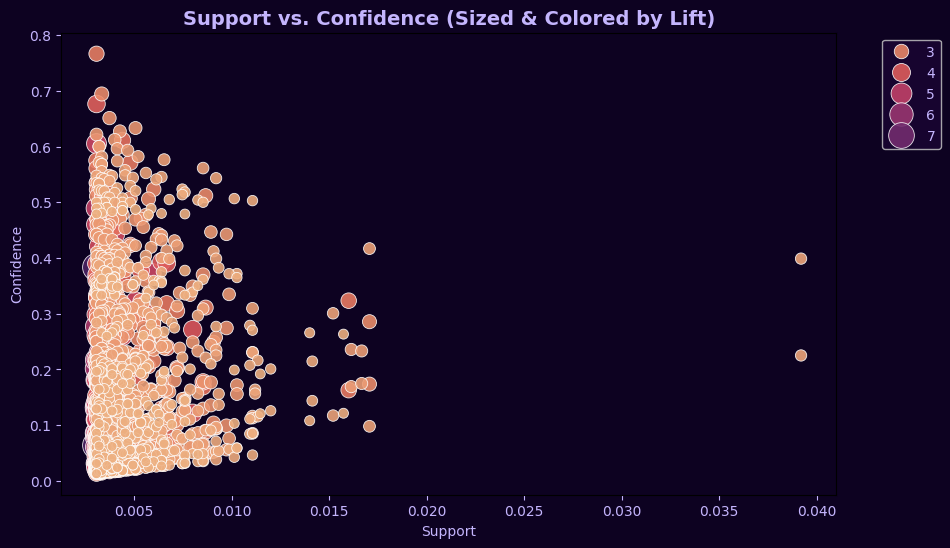

,antecedents,consequents,support,confidence,lift
1708,"frozenset({soup, frozen vegetables})","frozenset({mineral water, milk})",0.003066,0.383333,7.987176
1709,"frozenset({mineral water, milk})","frozenset({soup, frozen vegetables})",0.003066,0.063889,7.987176
1697,"frozenset({olive oil, frozen vegetables})","frozenset({mineral water, milk})",0.003333,0.294118,6.128268
1692,"frozenset({mineral water, milk})","frozenset({olive oil, frozen vegetables})",0.003333,0.069444,6.128268
1284,"frozenset({mineral water, whole wheat pasta})",frozenset({olive oil}),0.003866,0.402778,6.115863


In [13]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=2)
rules = rules.sort_values(by=["lift", "confidence"], ascending=False)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_facecolor('#0d0221')
plt.gcf().patch.set_facecolor('#0d0221')

sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules, sizes=(50, 400), palette="flare", alpha=0.9)
plt.title("Support vs. Confidence (Sized & Colored by Lift)", fontsize=14, fontweight='bold', color='#c4b5fd')
plt.xlabel("Support", color='#c4b5fd')
plt.ylabel("Confidence", color='#c4b5fd')
plt.tick_params(colors='#c4b5fd')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', facecolor='#1a0533', labelcolor='#c4b5fd')
plt.show()

# Displaying the top 5 most actionable business rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

### 7. Business Action Map (Network Visualization)
A Network Graph to visualize the connections between products. Arrows point from the antecedent (If you buy this) to the consequent (Then you buy this). Node size represents the strength of the connection.

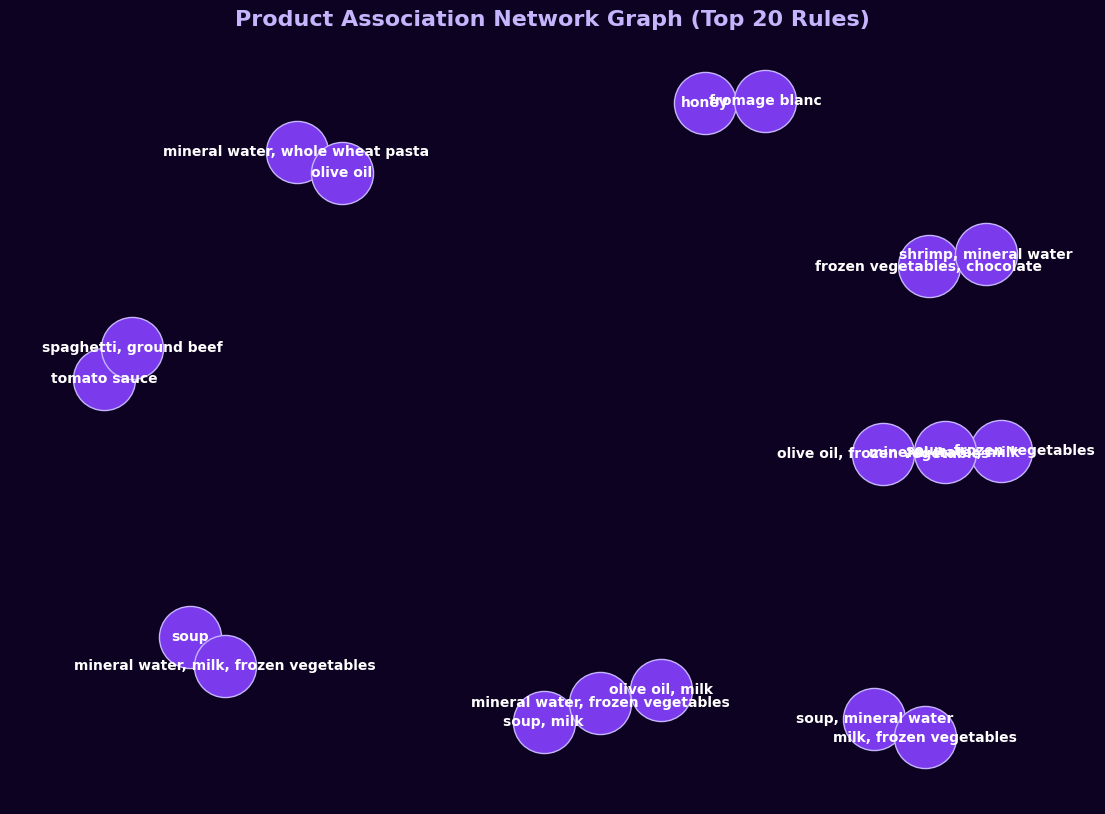

In [14]:
# Filtering top 20 rules for a cleaner graph
top_rules = rules.head(20)

G = nx.DiGraph()
for index, row in top_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(14, 10))
ax = plt.gca()
ax.set_facecolor('#0d0221')
plt.gcf().patch.set_facecolor('#0d0221')

pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='#7c3aed', edgecolors='#c4b5fd')
nx.draw_networkx_edges(G, pos, width=2, edge_color='#c4b5fd', arrowsize=20, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", font_color='white')

plt.title("Product Association Network Graph (Top 20 Rules)", fontsize=16, fontweight='bold', color='#c4b5fd')
plt.axis('off')
plt.show()

### 8. Lift Heatmap Matrix (Correlation Insight)
While network graphs show individual connections, a Heatmap allows us to view the cross-selling strength (Lift) across multiple product antecedents and consequents simultaneously in a matrix layout.

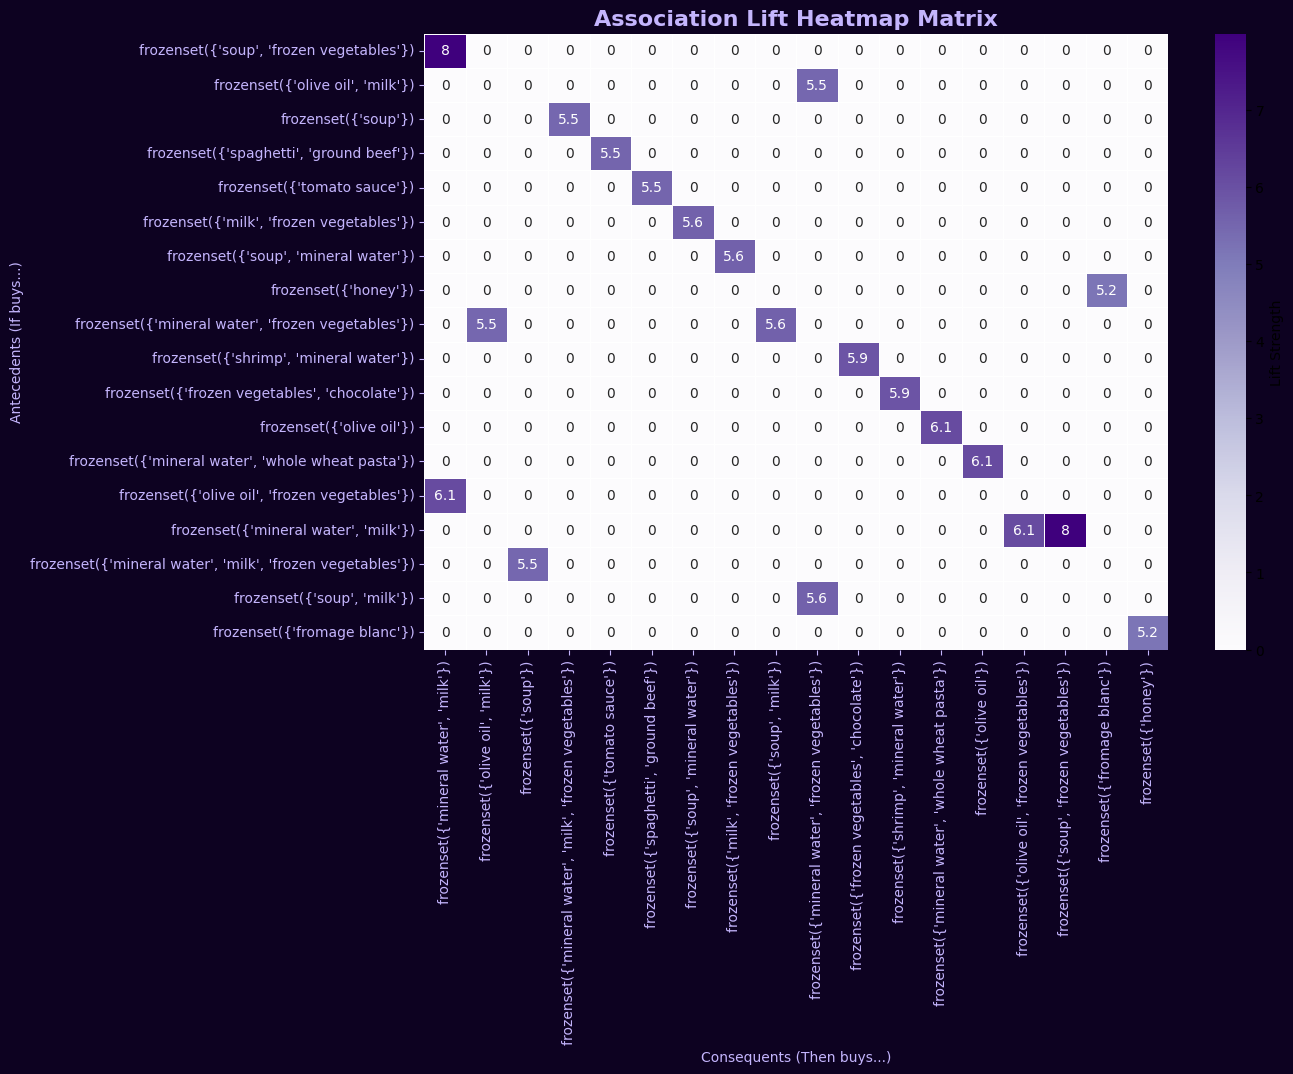

In [15]:
# Pivot the top rules to create a matrix format for the heatmap
pivot_rules = top_rules.pivot(index="antecedents", columns="consequents", values="lift")
pivot_rules = pivot_rules.fillna(0)  # Fill missing pairs with zero for clean rendering

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.set_facecolor('#0d0221')
plt.gcf().patch.set_facecolor('#0d0221')

# Plotting the heatmap with a purple palette to match the dark theme
sns.heatmap(pivot_rules, annot=True, cmap="Purples", linewidths=.5, cbar_kws={'label': 'Lift Strength'})
plt.title("Association Lift Heatmap Matrix", fontsize=16, fontweight='bold', color='#c4b5fd')
plt.xlabel("Consequents (Then buys...)", color='#c4b5fd')
plt.ylabel("Antecedents (If buys...)", color='#c4b5fd')
plt.tick_params(colors='#c4b5fd')
plt.show()